@author: eveomett

# Lab 3: MAUP and data.  See details on Canvas page

## Make sure to say where/when you got your data!

In [1]:
import sys
import pandas as pd
import geopandas as gpd
import maup
from maup import smart_repair
import time
import os

maup.progress.enabled = True

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# paths
population_path = ".\ma_pl2020_b\ma_pl2020_p1_b.shp"
election_path = ".\ma_2024_gen_prec\ma_2024_gen_all_prec\ma_2024_gen_all_prec.shp"
county_path = ".\ma_pl2020_cnty\ma_pl2020_cnty.shp"

# load data
pop_df = gpd.read_file(population_path)
county_df = gpd.read_file(county_path)
elec_df = gpd.read_file(election_path)

print("population rows:", len(pop_df))
print("county rows:", len(county_df))
print("election rows:", len(elec_df))

population rows: 107278
county rows: 14
election rows: 2383


In [4]:
# move everything to one UTM CRS
utm_crs = elec_df.estimate_utm_crs()

pop_df = pop_df.to_crs(utm_crs)
county_df = county_df.to_crs(utm_crs)
elec_df = elec_df.to_crs(utm_crs)

print(pop_df.crs)
print(county_df.crs)
print(elec_df.crs)

# doctor checks before repair
print("population doctor:", maup.doctor(pop_df))
print("county doctor:", maup.doctor(county_df))
print("election doctor:", maup.doctor(elec_df))

EPSG:32619
EPSG:32619
EPSG:32619


100%|█████████████████████████████████████████████████████████████████████████| 107278/107278 [03:21<00:00, 531.45it/s]


population doctor: True


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 69.01it/s]


county doctor: True


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:07<00:00, 319.09it/s]


There are 519 overlaps.
There are 77 holes.
There are some invalid geometries.
election doctor: False


In [5]:
# repair precincts inside counties
final_df = smart_repair(elec_df, nest_within_regions = county_df, snap_precision = 8)

# change small rook boundaries to queen adjacencies
final_df = smart_repair(final_df, min_rook_length = 30)

print("final doctor:", maup.doctor(final_df))

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 67.57it/s]


Snapping all geometries to a grid with precision 10^( -3 ) to avoid GEOS errors.


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 14.79it/s]


Identifying overlaps...


100%|█████████████████████████████████████████████████████████████████████████████| 8753/8753 [00:10<00:00, 835.57it/s]


...

Resolving overlaps...
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:07<00:00, 321.34it/s]


final doctor: True


In [6]:
# assign 2020 blocks to precincts and add total population
precinct_assignments = maup.assign(pop_df.geometry, final_df.geometry)

final_df["TOTPOP"] = pop_df["P0010001"].groupby(precinct_assignments).sum()
final_df["TOTPOP"] = final_df["TOTPOP"].fillna(0)

# keep district data from the precinct file
final_df["CD"] = final_df["CONG_DIST"]

# save shapefile
if not os.path.exists("MA"):
    os.mkdir("MA")

final_df.to_file(r"MA\MA.shp")

print("STACK SUMMARY")
print("precinct file used:", election_path)
print("population file used:", population_path)
print("county file used:", county_path)
print("doctor after repair:", maup.doctor(final_df))
print("total population in blocks:", pop_df["P0010001"].sum())
print("total population in final precincts:", final_df["TOTPOP"].sum())
print("number of districts:", final_df["CD"].nunique())
print(final_df["CD"].dropna().unique())

100%|██████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:32<00:00, 73.65it/s]


STACK SUMMARY
precinct file used: .\ma_2024_gen_prec\ma_2024_gen_all_prec\ma_2024_gen_all_prec.shp
population file used: .\ma_pl2020_b\ma_pl2020_p1_b.shp
county file used: .\ma_pl2020_cnty\ma_pl2020_cnty.shp


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:07<00:00, 319.39it/s]


doctor after repair: True
total population in blocks: 7029917
total population in final precincts: 7029917
number of districts: 9
['08' '03' '09' '01' '06' '02' '05' '04' '07']


In [7]:
# Run this first to see what election columns are available in final_df
print(final_df.columns.tolist())

['UNIQUE_ID', 'COUNTYFP', 'City/Town', 'Ward', 'Pct', 'County', 'CONG_DIST', 'SLDL_DIST', 'SLDU_DIST', 'G24PREDHAR', 'G24PRELOLI', 'G24PREOOTH', 'G24PRERTRU', 'G24PREUAYY', 'G24PREUCRU', 'G24PREUSON', 'G24PREUSTE', 'G24PREUWES', 'G24USSDWAR', 'G24USSOOTH', 'G24USSRDEA', 'GCON01DNEA', 'GCON01OOTH', 'GCON01UMIL', 'GCON02DMCG', 'GCON02OOTH', 'GCON02USHE', 'GCON03DTRA', 'GCON03OOTH', 'GCON04DAUC', 'GCON04OOTH', 'GCON04UFAD', 'GCON05DCLA', 'GCON05OOTH', 'GCON06DMOU', 'GCON06OOTH', 'GCON07DPRE', 'GCON07OOTH', 'GCON08DLYN', 'GCON08OOTH', 'GCON08RBUR', 'GCON09DKEA', 'GCON09OOTH', 'GCON09RSUL', 'GSLB01DLOU', 'GSLB01OOTH', 'GSLB01RCHA', 'GSLB02DHAW', 'GSLB02OOTH', 'GSLB02UBEL', 'GSLB02WNEL', 'GSLB03DDOH', 'GSLB03OOTH', 'GSLB04OOTH', 'GSLB04RHOW', 'GSLB05DHAD', 'GSLB05OOTH', 'GSLB05RTHU', 'GSLB06DFIO', 'GSLB06OOTH', 'GSLB07DSIL', 'GSLB07OOTH', 'GSLB08DOUE', 'GSLB08OOTH', 'GSLB08RTHR', 'GSLB08UGEL', 'GSLB08UHAD', 'GSLB08USOA', 'GSLB09DMAR', 'GSLB09OOTH', 'GSLB10DSYL', 'GSLB10OOTH', 'GSLB10RPIR', '

In [8]:
DEM_COL_1 = "G24PREDHAR"   # 2024 President - Harris (Democrat)
REP_COL_1 = "G24PRERTRU"   # 2024 President - Trump (Republican)

DEM_COL_2 = "G24USSDWAR"   # 2024 US Senate - Democrat
REP_COL_2 = "G24USSRDEA"   # 2024 US Senate - Republican

# Second election columns already exist in final_df — no file loading needed
# election2_path = ...
# elec2_df = ...
# final_df[DEM_COL_2] = ...
# final_df[REP_COL_2] = ...
# final_df.to_file(...)

In [9]:
# gerrychain imports
import networkx as nx
import gerrychain
from gerrychain import Graph, Partition, constraints, MarkovChain
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial
from gerrychain.constraints import contiguous

In [10]:
# build graph and initial partition
ma_graph = Graph.from_file(r"MA\MA.shp", adjacency = "queen",
    cols_to_add = ["TOTPOP", "CD", DEM_COL_1, REP_COL_1, DEM_COL_2, REP_COL_2])

print("Is graph connected?", nx.is_connected(ma_graph))
print("Number of nodes:", len(ma_graph.nodes()))
print("Number of edges:", len(ma_graph.edges()))

tot_pop = sum([ma_graph.nodes()[v]["TOTPOP"] for v in ma_graph.nodes()])
num_dist = len(set([ma_graph.nodes()[v]["CD"] for v in ma_graph.nodes()]))

ideal_pop = tot_pop / num_dist
pop_tolerance = 0.05

initial_plan = {v: ma_graph.nodes()[v]["CD"] for v in ma_graph.nodes()}

initial_partition = Partition(
    ma_graph,
    assignment = initial_plan,
    updaters = {
        "cut_edges": cut_edges,
        "district population": Tally("TOTPOP", alias = "district population"),
        "dem1": Tally(DEM_COL_1, alias = "dem1"),
        "rep1": Tally(REP_COL_1, alias = "rep1"),
        "dem2": Tally(DEM_COL_2, alias = "dem2"),
        "rep2": Tally(REP_COL_2, alias = "rep2"),
    }
)

print("initial partition contiguous?", contiguous(initial_partition))

C:\Users\anton\OneDrive\Pulpit\idkidk\cs463_final_jupyter\venv\Lib\site-packages\gerrychain\graph\graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {924, 1447}
  warnings.warn(


Is graph connected? False
Number of nodes: 2383
Number of edges: 6986
initial partition contiguous? False


district 07
district 08
district 09
{'boundary_node': False, 'area': 4517305.493465681, 'UNIQUE_ID': 'Abington Pct 1', 'COUNTYFP': 23, 'City/Town': 'Abington', 'Ward': '-', 'Pct': '1', 'County': 'Plymouth', 'CONG_DIST': '08', 'SLDL_DIST': 'P07', 'SLDU_DIST': 'NRP', 'G24PREDHAR': 1019, 'G24PRELOLI': 12, 'G24PREOOTH': 6, 'G24PRERTRU': 905, 'G24PREUAYY': 19, 'G24PREUCRU': 5, 'G24PREUSON': 0, 'G24PREUSTE': 15, 'G24PREUWES': 0, 'G24USSDWAR': 948, 'G24USSOOTH': 0, 'G24USSRDEA': 1012, 'GCON01DNEA': 0, 'GCON01OOTH': 0, 'GCON01UMIL': 0, 'GCON02DMCG': 0, 'GCON02OOTH': 0, 'GCON02USHE': 0, 'GCON03DTRA': 0, 'GCON03OOTH': 0, 'GCON04DAUC': 0, 'GCON04OOTH': 0, 'GCON04UFAD': 0, 'GCON05DCLA': 0, 'GCON05OOTH': 0, 'GCON06DMOU': 0, 'GCON06OOTH': 0, 'GCON07DPRE': 0, 'GCON07OOTH': 0, 'GCON08DLYN': 1179, 'GCON08OOTH': 1, 'GCON08RBUR': 739, 'GCON09DKEA': 0, 'GCON09OOTH': 0, 'GCON09RSUL': 0, 'GSLB01DLOU': 0, 'GSLB01OOTH': 0, 'GSLB01RCHA': 0, 'GSLB02DHAW': 0, 'GSLB02OOTH': 0, 'GSLB02UBEL': 0, 'GSLB02WNEL': 0, 'G

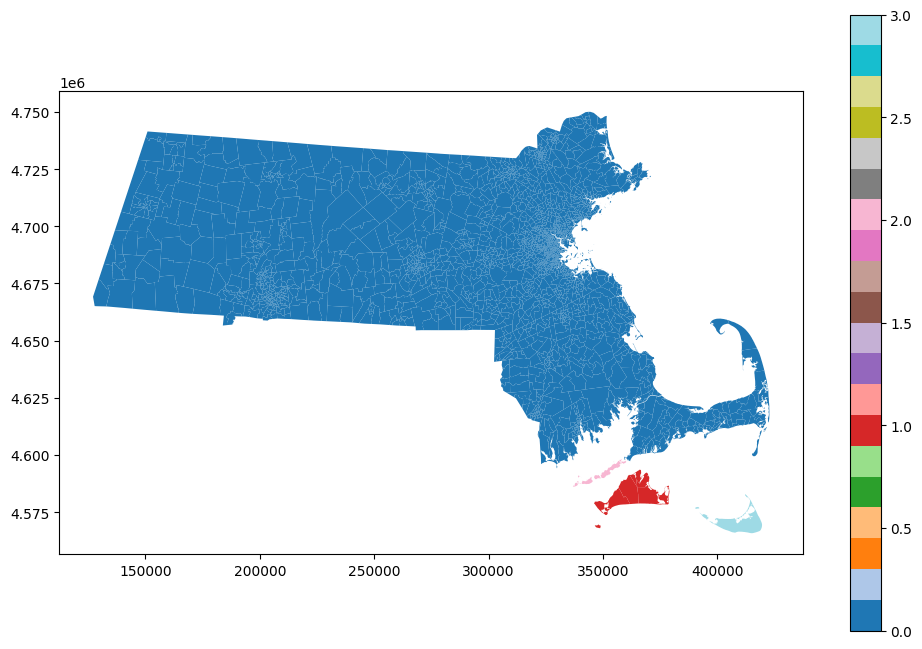

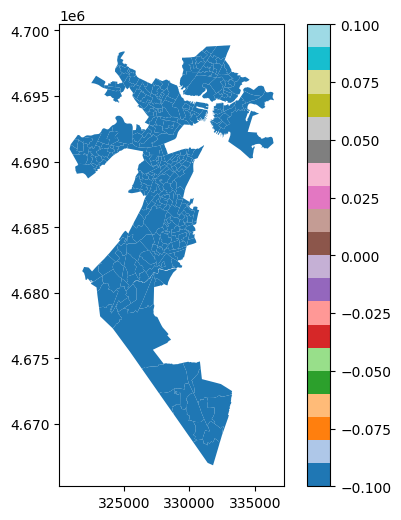

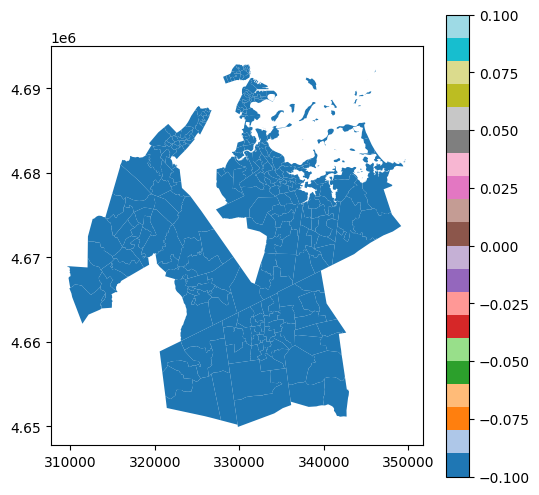

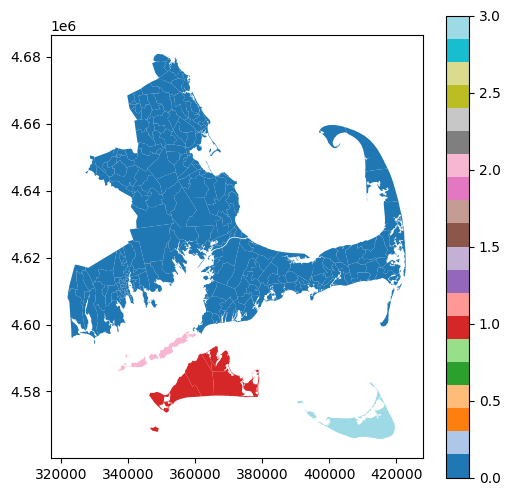

In [11]:
# optional map check to see disconnected pieces
df = gpd.read_file(r"MA\MA.shp")
df.index = list(ma_graph.nodes())

comp_id = {}
for i, comp in enumerate(nx.connected_components(ma_graph)):
    for v in comp:
        comp_id[v] = i

df["component"] = pd.Series(comp_id)

df.plot(column = "component", cmap = "tab20", figsize = (12,8), legend = True)

for d in ["07", "08", "09"]:
    df[df["CD"] == d].plot(column = "component", cmap = "tab20", figsize = (6,6), legend = True)
    print("district", d)

print(ma_graph.nodes[list(ma_graph.nodes())[0]])

In [12]:
# patch the graph by connecting the nearest disconnected pieces inside each district
temp_graph = nx.Graph(ma_graph)
centroids = df.geometry.centroid

for d in sorted(set(initial_plan.values())):
    verts_in_dist = [v for v in temp_graph.nodes() if initial_plan[v] == d]
    district = nx.subgraph(temp_graph, verts_in_dist)

    while not nx.is_connected(district):
        comps = sorted(nx.connected_components(district), key = len, reverse = True)
        main_comp = list(comps[0])
        other_comp = list(comps[1])

        best_u = None
        best_v = None
        best_dist = float("inf")

        for u in main_comp:
            for v in other_comp:
                dist = centroids.loc[u].distance(centroids.loc[v])
                if dist < best_dist:
                    best_dist = dist
                    best_u = u
                    best_v = v

        temp_graph.add_edge(best_u, best_v)
        print("added edge in district", d, "between", best_u, "and", best_v, "distance", round(best_dist, 2))

        district = nx.subgraph(temp_graph, verts_in_dist)

# put the needed node data back on the graph explicitly
for v in temp_graph.nodes():
    temp_graph.nodes[v]["TOTPOP"] = df.loc[v, "TOTPOP"]
    temp_graph.nodes[v]["CD"] = df.loc[v, "CD"]

ma_graph = gerrychain.Graph(temp_graph)

initial_partition = Partition(
    ma_graph,
    assignment = initial_plan,
    updaters = {
        "cut_edges": cut_edges,
        "district population": Tally("TOTPOP", alias = "district population"),
        "dem1": Tally(DEM_COL_1, alias = "dem1"),
        "rep1": Tally(REP_COL_1, alias = "rep1"),
        "dem2": Tally(DEM_COL_2, alias = "dem2"),
        "rep2": Tally(REP_COL_2, alias = "rep2"),
    }
)

print("graph connected now?", nx.is_connected(ma_graph))
print("initial partition contiguous now?", contiguous(initial_partition))
print(ma_graph.nodes[list(ma_graph.nodes())[0]])

added edge in district 07 between 629 and 199 distance 648.58
added edge in district 08 between 1701 and 264 distance 1210.47
added edge in district 08 between 427 and 385 distance 1310.3
added edge in district 08 between 436 and 191 distance 4343.66
added edge in district 09 between 830 and 2064 distance 10714.75
added edge in district 09 between 669 and 924 distance 13653.45
added edge in district 09 between 773 and 1447 distance 40816.46
graph connected now? True
initial partition contiguous now? True
{'boundary_node': False, 'area': 4517305.493465681, 'UNIQUE_ID': 'Abington Pct 1', 'COUNTYFP': 23, 'City/Town': 'Abington', 'Ward': '-', 'Pct': '1', 'County': 'Plymouth', 'CONG_DIST': '08', 'SLDL_DIST': 'P07', 'SLDU_DIST': 'NRP', 'G24PREDHAR': 1019, 'G24PRELOLI': 12, 'G24PREOOTH': 6, 'G24PRERTRU': 905, 'G24PREUAYY': 19, 'G24PREUCRU': 5, 'G24PREUSON': 0, 'G24PREUSTE': 15, 'G24PREUWES': 0, 'G24USSDWAR': 948, 'G24USSOOTH': 0, 'G24USSRDEA': 1012, 'GCON01DNEA': 0, 'GCON01OOTH': 0, 'GCON01UM

In [13]:
def efficiency_gap(partition, dem_key, rep_key):
    total_votes = 0
    wasted_dem = 0
    wasted_rep = 0
    for d in partition.parts:
        d_votes = partition[dem_key][d]
        r_votes = partition[rep_key][d]
        total = d_votes + r_votes
        total_votes += total
        threshold = total / 2 + 1
        if d_votes > r_votes:
            wasted_dem += d_votes - threshold
            wasted_rep += r_votes
        else:
            wasted_rep += r_votes - threshold
            wasted_dem += d_votes
    return (wasted_dem - wasted_rep) / total_votes

rw_proposal = partial(
    recom,
    pop_col = "TOTPOP",
    pop_target = ideal_pop,
    epsilon = pop_tolerance,
    node_repeats = 1
)

population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition,
    pop_tolerance,
    pop_key = "district population"
)

# --- Ensemble 1: 2024 Presidential ---
chain1 = MarkovChain(
    proposal = rw_proposal,
    constraints = [constraints.contiguous, population_constraint],
    accept = always_accept,
    initial_state = initial_partition,
    total_steps = 2000
)

eg1, dem_won1, cutedges1, margins1 = [], [], [], []

for part in chain1:
    cutedges1.append(len(part["cut_edges"]))
    dem_won1.append(sum(1 for d in part.parts if part["dem1"][d] > part["rep1"][d]))
    eg1.append(efficiency_gap(part, "dem1", "rep1"))
    margins1.append(sorted([
        part["dem1"][d] / (part["dem1"][d] + part["rep1"][d])
        for d in part.parts
        if (part["dem1"][d] + part["rep1"][d]) > 0
    ]))

print("Ensemble 1 done")

# --- Ensemble 2: 2024 US Senate ---
chain2 = MarkovChain(
    proposal = rw_proposal,
    constraints = [constraints.contiguous, population_constraint],
    accept = always_accept,
    initial_state = initial_partition,
    total_steps = 2000
)

eg2, dem_won2, cutedges2, margins2 = [], [], [], []

for part in chain2:
    cutedges2.append(len(part["cut_edges"]))
    dem_won2.append(sum(1 for d in part.parts if part["dem2"][d] > part["rep2"][d]))
    eg2.append(efficiency_gap(part, "dem2", "rep2"))
    margins2.append(sorted([
        part["dem2"][d] / (part["dem2"][d] + part["rep2"][d])
        for d in part.parts
        if (part["dem2"][d] + part["rep2"][d]) > 0
    ]))

print("Ensemble 2 done")

Ensemble 1 done
Ensemble 2 done


In [14]:
# final summary
print("FINAL SUMMARY")
print("final shapefile doctor:", maup.doctor(final_df))
print("block population total:", pop_df["P0010001"].sum())
print("precinct population total:", final_df["TOTPOP"].sum())
print("district count:", final_df["CD"].nunique())
print("graph connected:", nx.is_connected(ma_graph))
print("initial partition contiguous:", contiguous(initial_partition))

FINAL SUMMARY


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:07<00:00, 328.48it/s]


final shapefile doctor: True
block population total: 7029917
precinct population total: 7029917
district count: 9
graph connected: True
initial partition contiguous: True


In [15]:
import matplotlib.pyplot as plt

# actual MA map values
actual_cutedges = len(initial_partition["cut_edges"])
actual_dem_won1 = sum(1 for d in initial_partition.parts if initial_partition["dem1"][d] > initial_partition["rep1"][d])
actual_eg1 = efficiency_gap(initial_partition, "dem1", "rep1")
actual_dem_won2 = sum(1 for d in initial_partition.parts if initial_partition["dem2"][d] > initial_partition["rep2"][d])
actual_eg2 = efficiency_gap(initial_partition, "dem2", "rep2")
actual_margins1 = sorted([
    initial_partition["dem1"][d] / (initial_partition["dem1"][d] + initial_partition["rep1"][d])
    for d in initial_partition.parts
    if (initial_partition["dem1"][d] + initial_partition["rep1"][d]) > 0
])
actual_margins2 = sorted([
    initial_partition["dem2"][d] / (initial_partition["dem2"][d] + initial_partition["rep2"][d])
    for d in initial_partition.parts
    if (initial_partition["dem2"][d] + initial_partition["rep2"][d]) > 0
])

print("actual cut edges:", actual_cutedges)
print("actual dem won (pres):", actual_dem_won1, "| actual EG (pres):", round(actual_eg1, 4))
print("actual dem won (senate):", actual_dem_won2, "| actual EG (senate):", round(actual_eg2, 4))

actual cut edges: 659
actual dem won (pres): 9 | actual EG (pres): -0.2409
actual dem won (senate): 9 | actual EG (senate): -0.3015


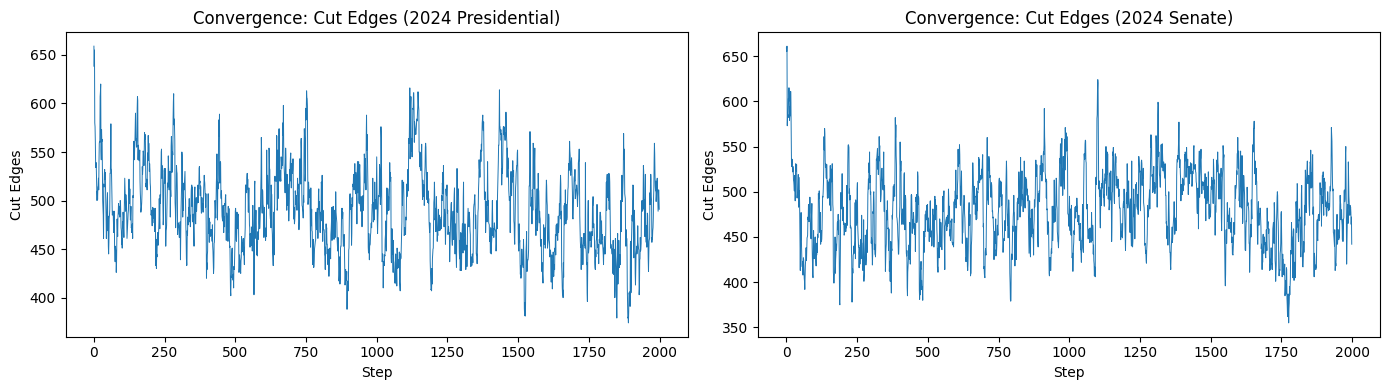

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(cutedges1, linewidth=0.7)
axes[0].set_title("Convergence: Cut Edges (2024 Presidential)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Cut Edges")

axes[1].plot(cutedges2, linewidth=0.7)
axes[1].set_title("Convergence: Cut Edges (2024 Senate)")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Cut Edges")

plt.tight_layout()
plt.savefig("convergence.png", dpi=150)
plt.show()

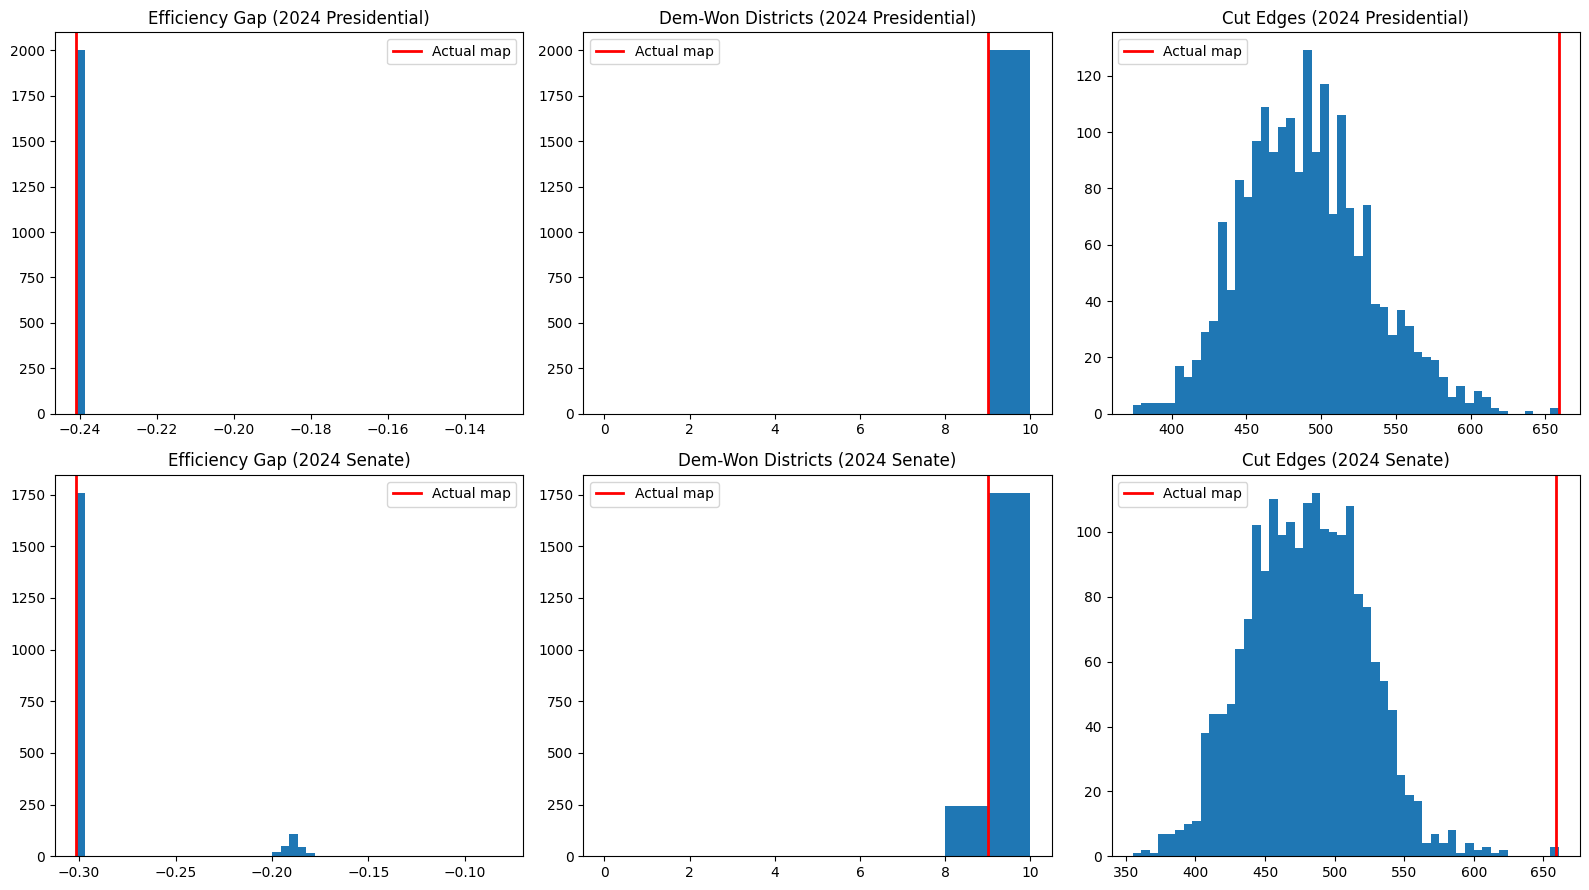

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: 2024 Presidential
axes[0][0].hist(eg1, bins=50)
axes[0][0].axvline(actual_eg1, color='red', linewidth=2, label='Actual map')
axes[0][0].set_title("Efficiency Gap (2024 Presidential)")
axes[0][0].legend()

axes[0][1].hist(dem_won1, bins=range(0, 11))
axes[0][1].axvline(actual_dem_won1, color='red', linewidth=2, label='Actual map')
axes[0][1].set_title("Dem-Won Districts (2024 Presidential)")
axes[0][1].legend()

axes[0][2].hist(cutedges1, bins=50)
axes[0][2].axvline(actual_cutedges, color='red', linewidth=2, label='Actual map')
axes[0][2].set_title("Cut Edges (2024 Presidential)")
axes[0][2].legend()

# Row 2: 2024 Senate
axes[1][0].hist(eg2, bins=50)
axes[1][0].axvline(actual_eg2, color='red', linewidth=2, label='Actual map')
axes[1][0].set_title("Efficiency Gap (2024 Senate)")
axes[1][0].legend()

axes[1][1].hist(dem_won2, bins=range(0, 11))
axes[1][1].axvline(actual_dem_won2, color='red', linewidth=2, label='Actual map')
axes[1][1].set_title("Dem-Won Districts (2024 Senate)")
axes[1][1].legend()

axes[1][2].hist(cutedges2, bins=50)
axes[1][2].axvline(actual_cutedges, color='red', linewidth=2, label='Actual map')
axes[1][2].set_title("Cut Edges (2024 Senate)")
axes[1][2].legend()

plt.tight_layout()
plt.savefig("histograms.png", dpi=150)
plt.show()

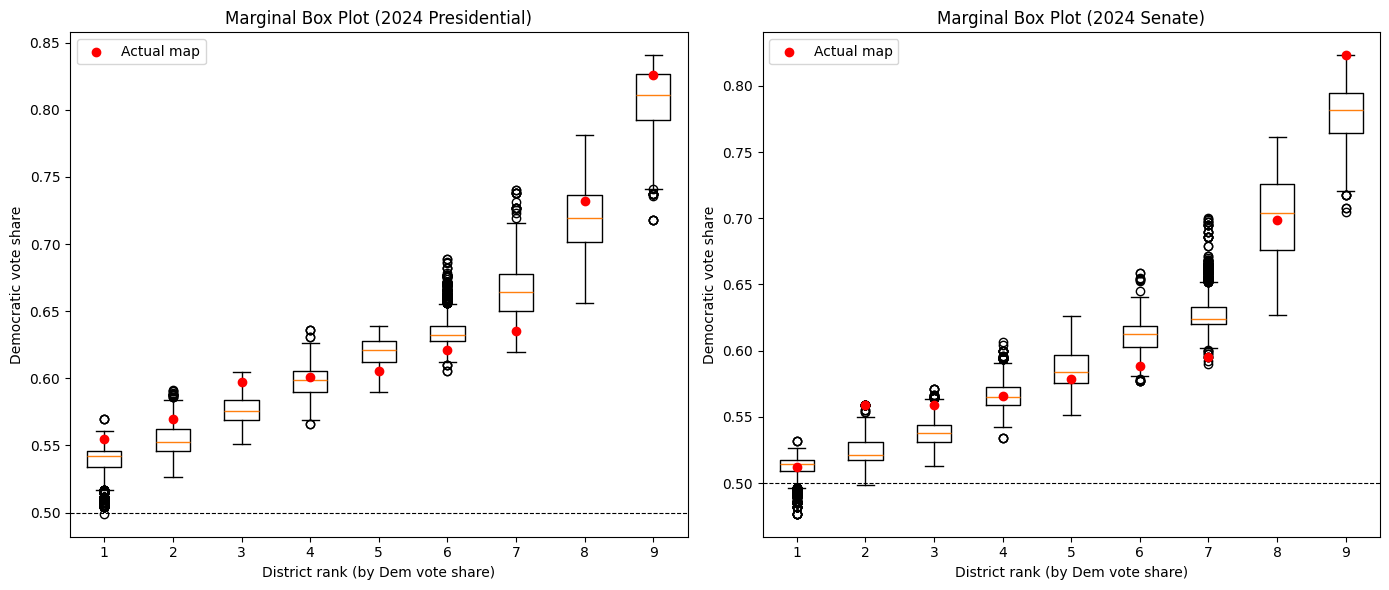

In [18]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
num_districts = len(actual_margins1)

# 2024 Presidential
box_data1 = [[margins1[step][d] for step in range(len(margins1))] for d in range(num_districts)]
axes[0].boxplot(box_data1, positions=range(1, num_districts + 1))
axes[0].scatter(range(1, num_districts + 1), actual_margins1, color='red', zorder=5, label='Actual map')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title("Marginal Box Plot (2024 Presidential)")
axes[0].set_xlabel("District rank (by Dem vote share)")
axes[0].set_ylabel("Democratic vote share")
axes[0].legend()

# 2024 Senate
box_data2 = [[margins2[step][d] for step in range(len(margins2))] for d in range(num_districts)]
axes[1].boxplot(box_data2, positions=range(1, num_districts + 1))
axes[1].scatter(range(1, num_districts + 1), actual_margins2, color='red', zorder=5, label='Actual map')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Marginal Box Plot (2024 Senate)")
axes[1].set_xlabel("District rank (by Dem vote share)")
axes[1].set_ylabel("Democratic vote share")
axes[1].legend()

plt.tight_layout()
plt.savefig("marginal_boxplots.png", dpi=150)
plt.show()